# **Universidad del Gran Rosario**

## Lic. En Ciencia de Datos

### Aprendizaje profundo

# Trabajo práctico N°: 1.

Alumno: Pace, Bruno Emmanuel.

Docentes:
- Bauman, Peter.
- Conti Simon, Bruno.

Trabajo Práctico Evaluativo N 1

Objetivo:

Desarrollar un modelo de clasificación de dígitos manuscritos utilizando el conjunto de datos MNIST y permitir probar el modelo con imágenes de dígitos creadas por uno (Crear dichas imagenes por nosotros, no descargarlas ni reutilizar imagenes de terceros).
Descripción:

    Entrenar un modelo de red neuronal en el conjunto de datos MNIST.

    Preprocesar imágenes nuevas creadas por los alumnos. Para este apartado los alumnos deberán crear un dataset de 3 a 5 imágenes propias de dígitos manuscritos los cuales utilizaran para predecir con el modelo entrenado.

    Deben mostrar cada predicción y el porcentaje de acierto para cada imagen.

Pasos Sugeridos:
1. Importar Librerías y Cargar el Conjunto de Datos MNIST
2. Preprocesamiento de Datos
3. Construcción y Entrenamiento del Modelo
4. Evaluación del Modelo
5. Preprocesamiento de Imágenes Nuevas
6. Predicción con el Modelo Entrenado


# Librerias y carga del dataset MNIST

In [1]:
import os
from typing import Tuple, List

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

In [2]:
def load_mnist_data() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Carga el conjunto de datos MNIST desde TensorFlow.

    Returns:
        Tuple con arrays de entrenamiento y prueba (x_train, y_train, x_test, y_test).
    """
    mnist = tf.keras.datasets.mnist
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    return x_train, y_train, x_test, y_test


x_train, y_train, x_test, y_test = load_mnist_data()

# Pre procesamiento de los datos - Normalización

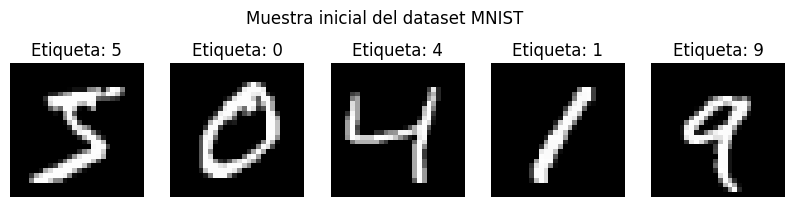

In [3]:
def visualize_samples(images: np.ndarray, labels: np.ndarray, num_samples: int = 5) -> None:
    """
    Despliega una muestra visual de imágenes del dataset junto con sus etiquetas.
    """
    plt.figure(figsize=(10, 2))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Etiqueta: {labels[i]}")
        plt.axis('off')

    plt.suptitle("Muestra inicial del dataset MNIST", y=1.1)
    plt.show()


def preprocess_data_cnn(x_train: np.ndarray, x_test: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Normaliza los píxeles al rango [0, 1] y añade la dimensión del canal (escala de grises)
    requerida por las capas Conv2D.

    Returns:
        Tuple con arrays de forma (muestras, 28, 28, 1).
    """
    x_train_norm: np.ndarray = x_train / 255.0
    x_test_norm: np.ndarray = x_test / 255.0

    # Expandir dimensiones para agregar el canal único necesario para la CNN
    x_train_cnn: np.ndarray = np.expand_dims(x_train_norm, axis=-1)
    x_test_cnn: np.ndarray = np.expand_dims(x_test_norm, axis=-1)

    return x_train_cnn, x_test_cnn


visualize_samples(x_train, y_train, num_samples=5)
x_train, x_test = preprocess_data_cnn(x_train, x_test)

Aunque MNIST es un dataset conocido, igualmente se visualizan algunos datos con los que vamos a trabajar.

# Construcción del modelo

Se optó por una arquitectura CNN para la red porque es lo más utilizado para imágenes, sin embargo dada la baja complejidad del problema también se podría utilizar una red neuronal fully connected (densa) y daría buenos resultados de la misma manera.

In [4]:
def build_and_train_cnn(
    x_train: np.ndarray,
    y_train: np.ndarray,
    epochs: int = 5,
    validation_split: float = 0.1
) -> Tuple[tf.keras.Model, tf.keras.callbacks.History]:
    """
    Construye, compila y entrena una CNN básica.
    Utiliza 1 capa Conv2D simple y 1 MaxPooling para no sobredimensionar la red.
    """
    model: tf.keras.Model = models.Sequential([
        # Capa de extracción de características
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),

        # Clasificador denso tradicional
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history: tf.keras.callbacks.History = model.fit(
        x_train,
        y_train,
        epochs=epochs,
        validation_split=validation_split
    )
    return model, history


model, history = build_and_train_cnn(x_train, y_train)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9387 - loss: 0.2055 - val_accuracy: 0.9775 - val_loss: 0.0725
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9769 - loss: 0.0770 - val_accuracy: 0.9853 - val_loss: 0.0491
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9835 - loss: 0.0522 - val_accuracy: 0.9870 - val_loss: 0.0470
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9878 - loss: 0.0398 - val_accuracy: 0.9883 - val_loss: 0.0422
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9905 - loss: 0.0305 - val_accuracy: 0.9843 - val_loss: 0.0564


Tenemos un accuracy de 0.99 prácticamente tanto para train como para validación. El modelo funciona de forma excepcional y no sufre overfitting.

# Evaluación

Si bien ya vimos que la métrica accuracy es muy buena, resulta de interés evaluar F1-score para ver el desempeño del modelo en cuanto a cada clase y una matriz de confusión para sumar a este análisis.


--- Rendimiento Global del Modelo ---
            Métrica    Valor
F1-Score (Weighted) 0.985398
           Accuracy 0.985400
-------------------------------------



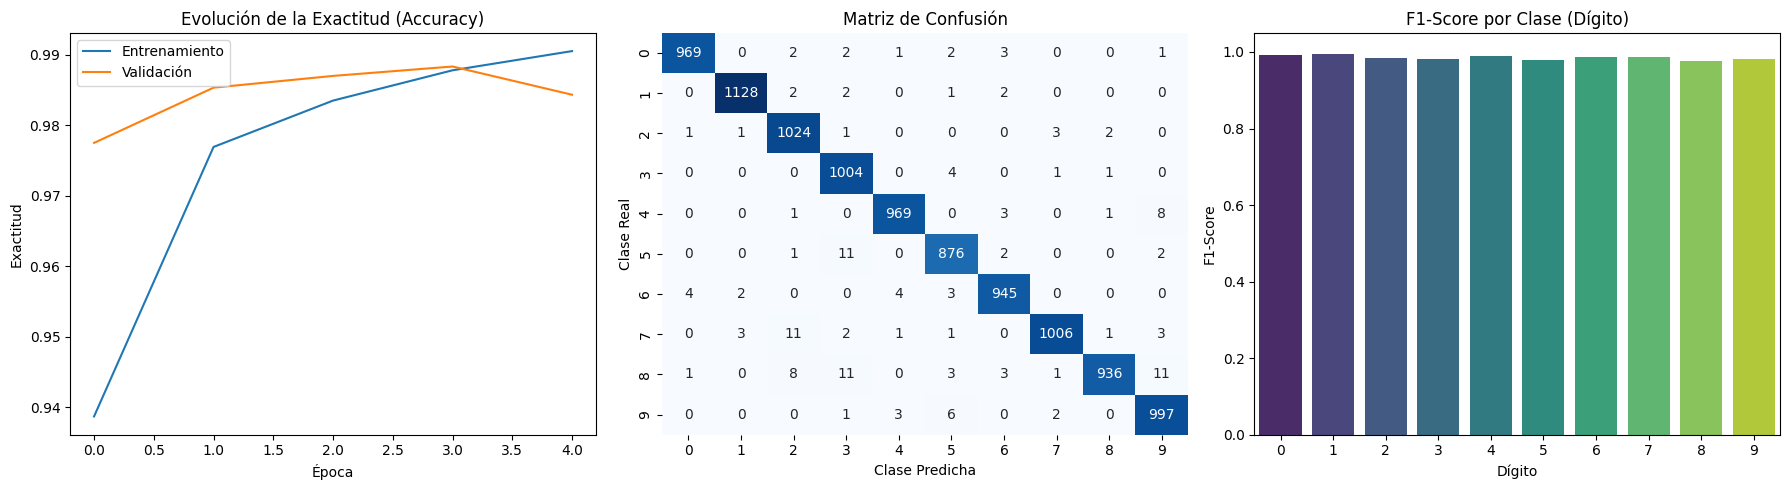

In [5]:
def evaluate_model(
    model: tf.keras.Model,
    x_test: np.ndarray,
    y_test: np.ndarray,
    history: tf.keras.callbacks.History
) -> None:
    """
    Evalúa el desempeño del modelo usando métricas globales y gráficos detallados,
    incluyendo el F1-Score por clase.

    Args:
        model (tf.keras.Model): Modelo entrenado.
        x_test (np.ndarray): Imágenes de prueba.
        y_test (np.ndarray): Etiquetas reales de prueba.
        history (tf.keras.callbacks.History): Historial del entrenamiento.
    """
    # Generación de predicciones
    y_pred_probs: np.ndarray = model.predict(x_test, verbose=0)
    y_pred: np.ndarray = np.argmax(y_pred_probs, axis=1)

    # Cálculo de métricas globales
    acc: float = accuracy_score(y_test, y_pred)
    f1_weighted: float = f1_score(y_test, y_pred, average='weighted')

    # Cálculo de F1-Score por clase (para el gráfico)
    f1_per_class: np.ndarray = f1_score(y_test, y_pred, average=None)

    # Visualización de métricas tabulares
    df_metrics = pd.DataFrame({
        'Métrica': ['F1-Score (Weighted)', 'Accuracy'],
        'Valor': [f1_weighted, acc]
    })
    print("\n--- Rendimiento Global del Modelo ---")
    print(df_metrics.to_string(index=False))
    print("-" * 37 + "\n")

    # Configuración de lienzo para gráficos (1 fila, 3 columnas)
    plt.figure(figsize=(18, 5))

    # Gráfico 1: Evolución del Accuracy
    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title('Evolución de la Exactitud (Accuracy)')
    plt.xlabel('Época')
    plt.ylabel('Exactitud')
    plt.legend()

    # Gráfico 2: Matriz de Confusión
    cm: np.ndarray = confusion_matrix(y_test, y_pred)
    plt.subplot(1, 3, 2)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Matriz de Confusión')
    plt.xlabel('Clase Predicha')
    plt.ylabel('Clase Real')

    # Gráfico 3: F1-Score por Clase
    plt.subplot(1, 3, 3)
    classes: List[str] = [str(i) for i in range(10)]
    sns.barplot(x=classes, y=f1_per_class, hue=classes, palette='viridis', legend=False)
    plt.title('F1-Score por Clase (Dígito)')
    plt.xlabel('Dígito')
    plt.ylabel('F1-Score')
    plt.ylim(0.0, 1.05)  # Margen superior para que la barra de 1.0 no toque el borde

    plt.tight_layout()
    plt.show()


# Ejecución de la evaluación
evaluate_model(model, x_test, y_test, history)

El modelo presenta un desempeño excelente, alcanzando Accuracy de 0.9854 y un F1-Score ponderado de 0.985398. La gran similitud entre ambos indicadores confirma que el rendimiento general es sumamente alto y equilibrado.

Al analizar el gráfico de evolución de la exactitud, se observa que la curva de validación crece acompañando al entrenamiento y alcanza su punto máximo alrededor de la época 3. Hacia la época 4, se percibe una muy leve caída en la validación mientras el entrenamiento sigue en ascenso. Esto indica el inicio natural de un ligero sobreajuste (overfitting), marcando que las 5 épocas configuradas son la cantidad óptima para este modelo antes de que pierda capacidad de generalización.

La matriz de confusión ratifica la solidez del clasificador, concentrando casi la totalidad de las predicciones en la diagonal principal. Los errores detectados son mínimos y responden a la similitud morfológica esperable en la caligrafía humana; las confusiones más repetidas se dieron al predecir un 3 cuando el dígito real era un 5 (11 casos), y al predecir un 2 cuando el dígito real era un 7 (11 casos).

Finalmente, el gráfico de F1-Score por clase exhibe barras que rozan el valor de 1.0 para todos los números, demostrando empíricamente que la red neuronal convolucional aprendió a extraer las características espaciales de los diez dígitos por igual, sin presentar sesgos de predicción hacia ninguna clase en particular.

# Imágenes propias

## Pre procesamiento

descarga de imágenes en caso que no existan.

In [6]:
folder_data_path = os.path.join(os.getcwd(), 'data')

if not os.path.exists(folder_data_path):
    os.system('git clone https://github.com/bpace1/MnistNeuralNetwork && mv MnistNeuralNetwork/data . && rm -rf MnistNeuralNetwork')
    print("Imágenes cargadas")
else:
  print("Las imágenes ya existen.")

Las imágenes ya existen.


pre procesamiento y predicción de imágenes propias, hechas a mano. Se hace una detección de bordes y un padding para que dada cualquier imágen que se ingrese, se pre procese y tome un formato similar a los datos de MNIST para maximizar el rendimiento del modelo.

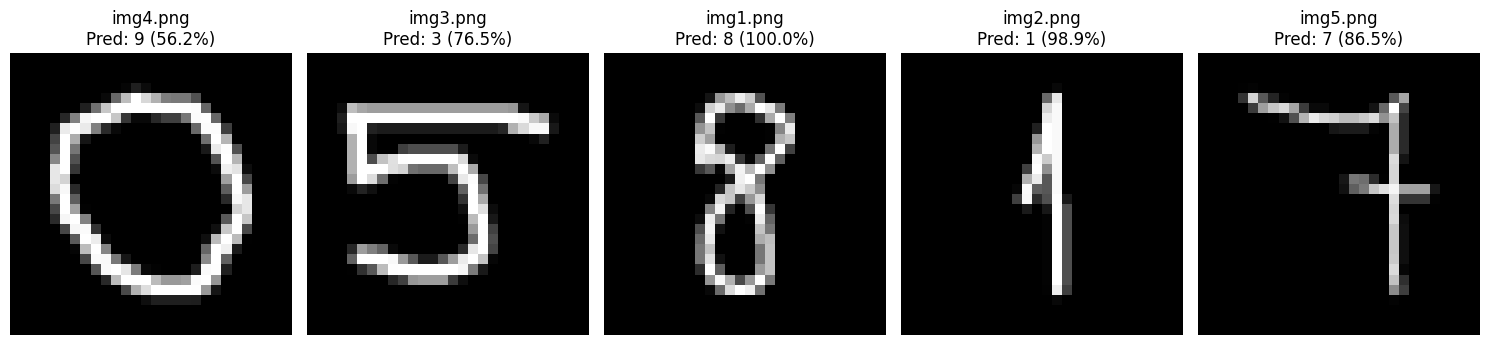

In [7]:
def preprocess_and_crop(img_gray: np.ndarray) -> np.ndarray:
    """
    Invierte la imagen, recorta los márgenes vacíos (bounding box),
    la convierte en un cuadrado perfecto sin deformarla y la redimensiona a 28x28.
    """
    # Invertir colores (fondo negro, trazo blanco)
    img_inv = cv2.bitwise_not(img_gray)

    # Aplicar threshold para asegurar que el fondo sea exactamente 0
    _, thresh = cv2.threshold(img_inv, 15, 255, cv2.THRESH_BINARY)

    # Encontrar las coordenadas de los píxeles
    coords = cv2.findNonZero(thresh)

    if coords is not None:
        # Obtener la caja delimitadora (x, y, ancho, alto)
        x, y, w, h = cv2.boundingRect(coords)
        img_cropped = img_inv[y:y+h, x:x+w]

        # 1. Preservar proporciones: hacer la imagen cuadrada rellenando el lado más corto
        max_dim = max(w, h)
        pad_top = (max_dim - h) // 2
        pad_bottom = (max_dim - h) - pad_top
        pad_left = (max_dim - w) // 2
        pad_right = (max_dim - w) - pad_left

        img_squared = cv2.copyMakeBorder(
            img_cropped, pad_top, pad_bottom, pad_left, pad_right,
            cv2.BORDER_CONSTANT, value=0
        )

        # 2. Calcular un margen (padding) imitando a MNIST
        pad_margin = int(max_dim * 0.2)
        img_padded = cv2.copyMakeBorder(
            img_squared, pad_margin, pad_margin, pad_margin, pad_margin,
            cv2.BORDER_CONSTANT, value=0
        )
    else:
        # Fallback
        img_padded = img_inv

    # Redimensionar al tamaño final sin deformar el trazo original
    img_resized = cv2.resize(img_padded, (28, 28), interpolation=cv2.INTER_AREA)
    return img_resized

def predict_custom_images_cnn_v2(model: tf.keras.Model, folder_path: str = folder_data_path) -> None:
    """
    Carga imágenes propias, aplica recorte dinámico,
    da formato de tensor (1, 28, 28, 1) y predice.
    """
    if not os.path.exists(folder_path):
        print(f"No se encontró el directorio '{folder_path}'.")
        return

    valid_exts: Tuple[str, ...] = ('.png', '.jpg', '.jpeg')
    image_files: List[str] = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(valid_exts)
    ]

    if not image_files:
        print(f"Directorio '{folder_path}' vacío o sin imágenes válidas.")
        return

    plt.figure(figsize=(15, 4))

    for i, file_name in enumerate(image_files):
        img_path: str = os.path.join(folder_path, file_name)
        img: np.ndarray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        # Aplicar el nuevo preprocesamiento
        img_processed: np.ndarray = preprocess_and_crop(img)

        # Normalizar
        img_normalized: np.ndarray = img_processed / 255.0

        # Expandir dimensiones a (1, 28, 28, 1)
        img_input: np.ndarray = np.expand_dims(img_normalized, axis=(0, -1))

        # Inferir
        prediction: np.ndarray = model.predict(img_input, verbose=0)
        predicted_class: int = int(np.argmax(prediction))
        confidence: float = float(np.max(prediction) * 100)

        # Visualizar
        plt.subplot(1, len(image_files), i + 1)
        plt.imshow(img_processed, cmap='gray')
        plt.title(
            f"{file_name}\n"
            f"Pred: {predicted_class} ({confidence:.1f}%)"
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Ejecutar con el preprocesamiento avanzado
predict_custom_images_cnn_v2(model, folder_path=folder_data_path)

Obtenemos un modelo que generaliza correctamente, siendo el 5 un caso donde se equivoca (ya lo habiamos anticipado en la matriz de confusión) pero en los demás números de prueba, funciona bien.